In [10]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text
from scipy.stats import norm

In [11]:
DB_USER = "postgres"
DB_PASS = "laleh"
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "equity_risk_project"

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

with engine.connect() as conn:
    print(conn.execute(text("SELECT 1")).fetchone())

(1,)


In [12]:
OUTPUT_DIR = "outputs"
FIG_DIR = "figures"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

print("Folders ready")

Folders ready


In [13]:
SCENARIOS = pd.DataFrame({
    "scenario": [
        "Mild shock (-3%)",
        "Moderate shock (-5%)",
        "Severe shock (-10%)",
        "Crash shock (-20%)",
        "Volatility spike (sigma x2)"
    ],
    "shock_return": [-0.03, -0.05, -0.10, -0.20, np.nan],
    "vol_multiplier": [1.0, 1.0, 1.0, 1.0, 2.0]
})

SCENARIOS

,scenario,shock_return,vol_multiplier
0,Mild shock (-3%),-0.03,1.0
1,Moderate shock (-5%),-0.05,1.0
2,Severe shock (-10%),-0.10,1.0
3,Crash shock (-20%),-0.20,1.0
4,Volatility spike (sigma x2),NaN,2.0


In [14]:
SCENARIOS.to_csv(f"{OUTPUT_DIR}/day7_stress_scenarios.csv", index=False)

print("Saved scenario table")

Saved scenario table


In [15]:
r = pd.read_sql("SELECT date, ticker, daily_return FROM returns;", engine)
w = pd.read_sql("SELECT ticker, weight FROM portfolio_weights;", engine)

r["date"] = pd.to_datetime(r["date"])

df = r.merge(w, on="ticker")
df["weighted_return"] = df["daily_return"] * df["weight"]

df_ret = (df.groupby("date", as_index=False)["weighted_return"]
            .sum()
            .rename(columns={"weighted_return": "portfolio_return"})
            .sort_values("date"))

df_ret.head()

,date,portfolio_return
0,2019-01-02,0.000000
1,2019-01-03,-0.051894
2,2019-01-04,0.045667
3,2019-01-07,0.011638
4,2019-01-08,0.002726


In [16]:
ROLL_WINDOW = 100

df_ret["mu"] = df_ret["portfolio_return"].rolling(ROLL_WINDOW).mean()
df_ret["sigma"] = df_ret["portfolio_return"].rolling(ROLL_WINDOW).std()

df_bt = df_ret.dropna().copy()

latest_mu = df_bt["mu"].iloc[-1]
latest_sigma = df_bt["sigma"].iloc[-1]

latest_mu, latest_sigma

(np.float64(0.001574304580688477), np.float64(0.011260972711019605))

In [17]:
results = []

for _, row in SCENARIOS.iterrows():

    if pd.notna(row["shock_return"]):
        stressed_return = row["shock_return"]
    else:
        stressed_return = latest_mu

    stressed_sigma = latest_sigma * row["vol_multiplier"]

    results.append({
        "scenario": row["scenario"],
        "stressed_return": stressed_return,
        "stressed_loss": -stressed_return,
        "volatility_used": stressed_sigma
    })

stress_results = pd.DataFrame(results)

stress_results

,scenario,stressed_return,stressed_loss,volatility_used
0,Mild shock (-3%),-0.030000,0.030000,0.011261
1,Moderate shock (-5%),-0.050000,0.050000,0.011261
2,Severe shock (-10%),-0.100000,0.100000,0.011261
3,Crash shock (-20%),-0.200000,0.200000,0.011261
4,Volatility spike (sigma x2),0.001574,-0.001574,0.022522


In [18]:
stress_results.to_csv(f"{OUTPUT_DIR}/day7_stress_results.csv", index=False)

print("Saved stress test results")

Saved stress test results


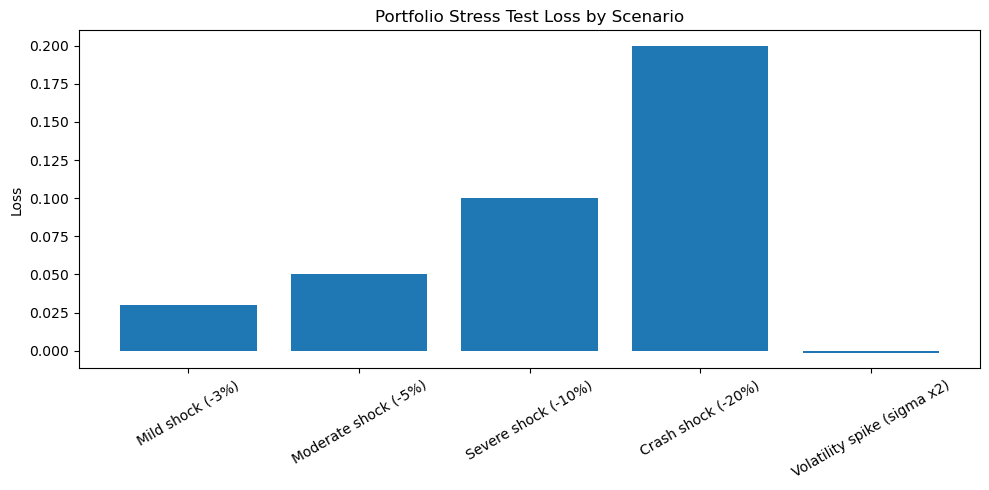

In [19]:
plt.figure(figsize=(10,5))

plt.bar(stress_results["scenario"], stress_results["stressed_loss"])

plt.title("Portfolio Stress Test Loss by Scenario")
plt.ylabel("Loss")
plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig(f"{FIG_DIR}/day7_stress_losses.png", dpi=300)

plt.show()

In [20]:
from scipy.stats import norm
import numpy as np
import pandas as pd

ALPHA_95 = 0.05
ALPHA_99 = 0.01

z_95 = norm.ppf(ALPHA_95)  # ~ -1.645
z_99 = norm.ppf(ALPHA_99)  # ~ -2.326

rows = []

for _, s in SCENARIOS.iterrows():
    scenario = s["scenario"]
    shock_return = s["shock_return"]
    vol_mult = float(s["vol_multiplier"])

    # Stressed mu: use shock if provided; otherwise baseline mu
    mu_stress = float(shock_return) if pd.notna(shock_return) else float(latest_mu)

    # Stressed sigma: multiply baseline sigma
    sigma_stress = float(latest_sigma) * vol_mult

    # VaR as POSITIVE loss number
    var95 = -(mu_stress + z_95 * sigma_stress)
    var99 = -(mu_stress + z_99 * sigma_stress)

    rows.append({
        "scenario": scenario,
        "mu_stress": mu_stress,
        "sigma_stress": sigma_stress,
        "VaR_95_stressed": var95,
        "VaR_99_stressed": var99
    })

stressed_var = pd.DataFrame(rows)
stressed_var

,scenario,mu_stress,sigma_stress,VaR_95_stressed,VaR_99_stressed
0,Mild shock (-3%),-0.030000,0.011261,0.048523,0.056197
1,Moderate shock (-5%),-0.050000,0.011261,0.068523,0.076197
2,Severe shock (-10%),-0.100000,0.011261,0.118523,0.126197
3,Crash shock (-20%),-0.200000,0.011261,0.218523,0.226197
4,Volatility spike (sigma x2),0.001574,0.022522,0.035471,0.050820


In [21]:
stressed_var.to_csv(f"{OUTPUT_DIR}/day7_stressed_var_table.csv", index=False)
print("Saved:", f"{OUTPUT_DIR}/day7_stressed_var_table.csv")

Saved: outputs/day7_stressed_var_table.csv


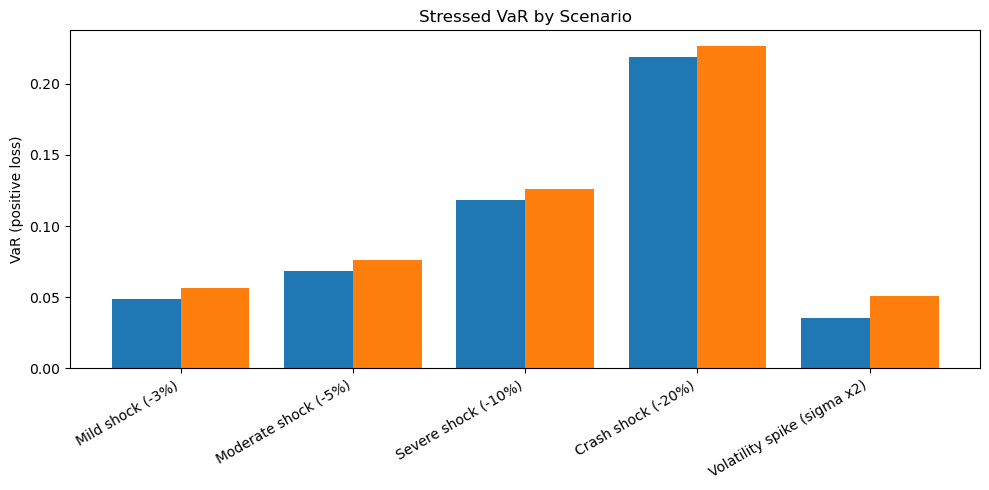

Saved: figures/day7_stressed_var_by_scenario.png


In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
x = np.arange(len(stressed_var))

plt.bar(x - 0.2, stressed_var["VaR_95_stressed"], width=0.4, label="VaR 95%")
plt.bar(x + 0.2, stressed_var["VaR_99_stressed"], width=0.4, label="VaR 99%")

plt.xticks(x, stressed_var["scenario"], rotation=30, ha="right")
plt.title("Stressed VaR by Scenario")
plt.ylabel("VaR (positive loss)")
plt.tight_layout()

plt.savefig(f"{FIG_DIR}/day7_stressed_var_by_scenario.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", f"{FIG_DIR}/day7_stressed_var_by_scenario.png")

In [23]:
stress_summary = stress_results.merge(
    stressed_var[["scenario","VaR_95_stressed","VaR_99_stressed"]],
    on="scenario"
)

stress_summary

,scenario,stressed_return,stressed_loss,volatility_used,VaR_95_stressed,VaR_99_stressed
0,Mild shock (-3%),-0.030000,0.030000,0.011261,0.048523,0.056197
1,Moderate shock (-5%),-0.050000,0.050000,0.011261,0.068523,0.076197
2,Severe shock (-10%),-0.100000,0.100000,0.011261,0.118523,0.126197
3,Crash shock (-20%),-0.200000,0.200000,0.011261,0.218523,0.226197
4,Volatility spike (sigma x2),0.001574,-0.001574,0.022522,0.035471,0.050820


In [24]:
def classify_risk(loss):
    
    if loss < 0.05:
        return "Low"
    elif loss < 0.10:
        return "Moderate"
    else:
        return "Severe"

stress_summary["risk_level"] = stress_summary["stressed_loss"].apply(classify_risk)

stress_summary

,scenario,stressed_return,stressed_loss,volatility_used,VaR_95_stressed,VaR_99_stressed,risk_level
0,Mild shock (-3%),-0.030000,0.030000,0.011261,0.048523,0.056197,Low
1,Moderate shock (-5%),-0.050000,0.050000,0.011261,0.068523,0.076197,Moderate
2,Severe shock (-10%),-0.100000,0.100000,0.011261,0.118523,0.126197,Severe
3,Crash shock (-20%),-0.200000,0.200000,0.011261,0.218523,0.226197,Severe
4,Volatility spike (sigma x2),0.001574,-0.001574,0.022522,0.035471,0.050820,Low


In [25]:
stress_summary.to_csv(f"{OUTPUT_DIR}/day7_stress_summary.csv", index=False)

print("Saved:", f"{OUTPUT_DIR}/day7_stress_summary.csv")

Saved: outputs/day7_stress_summary.csv


In [26]:
r = pd.read_sql("SELECT date, ticker, daily_return FROM returns;", engine)
w = pd.read_sql("SELECT ticker, weight FROM portfolio_weights;", engine)

r["date"] = pd.to_datetime(r["date"])

df = r.merge(w, on="ticker")

df.head()

,date,ticker,daily_return,weight
0,2019-01-02,AAPL,NaN,0.25
1,2019-01-03,AAPL,-0.099608,0.25
2,2019-01-04,AAPL,0.042689,0.25
3,2019-01-07,AAPL,-0.002226,0.25
4,2019-01-08,AAPL,0.019063,0.25


In [27]:
returns_matrix = df.pivot(
    index="date",
    columns="ticker",
    values="daily_return"
)

returns_matrix = returns_matrix.dropna()

returns_matrix.head()

ticker,AAPL,JPM,MSFT,NVDA,SPY
date,,,,,
2019-01-03,-0.099608,-0.014212,-0.036788,-0.060417,-0.023863
2019-01-04,0.042689,0.036866,0.046509,0.064067,0.033496
2019-01-07,-0.002226,0.000695,0.001275,0.052941,0.007885
2019-01-08,0.019063,-0.001886,0.007251,-0.024895,0.009395
2019-01-09,0.016982,-0.001691,0.014300,0.019667,0.004673


In [28]:
cov_matrix = returns_matrix.cov()

cov_matrix

ticker,AAPL,JPM,MSFT,NVDA,SPY
ticker,,,,,
AAPL,0.000377,0.000155,0.000261,0.000383,0.000190
JPM,0.000155,0.000373,0.000149,0.000212,0.000170
MSFT,0.000261,0.000149,0.000334,0.000401,0.000187
NVDA,0.000383,0.000212,0.000401,0.001068,0.000284
SPY,0.000190,0.000170,0.000187,0.000284,0.000156


In [29]:
weights = w.set_index("ticker")["weight"]

portfolio_var = np.dot(weights.T, np.dot(cov_matrix, weights))
portfolio_vol = np.sqrt(portfolio_var)

portfolio_vol

np.float64(0.016366835388609106)

In [30]:
marginal_risk = cov_matrix.dot(weights) / portfolio_vol

risk_contribution = weights * marginal_risk

risk_contribution = pd.DataFrame({
    "ticker": weights.index,
    "weight": weights.values,
    "risk_contribution": risk_contribution.values
})

risk_contribution

,ticker,weight,risk_contribution
0,AAPL,0.25,0.004398
1,MSFT,0.25,0.001833
2,NVDA,0.20,0.004264
3,JPM,0.15,0.005915
4,SPY,0.15,0.001833


In [31]:
risk_contribution["percent_risk"] = (
    risk_contribution["risk_contribution"] / portfolio_vol
)

risk_contribution

,ticker,weight,risk_contribution,percent_risk
0,AAPL,0.25,0.004398,0.268686
1,MSFT,0.25,0.001833,0.111999
2,NVDA,0.20,0.004264,0.260548
3,JPM,0.15,0.005915,0.361396
4,SPY,0.15,0.001833,0.111976


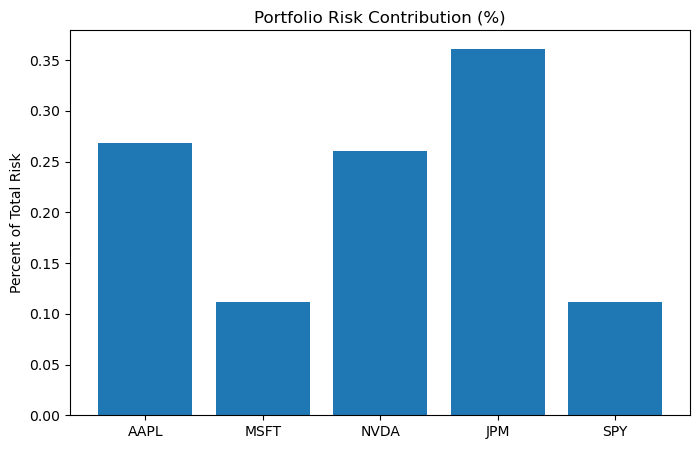

In [32]:
plt.figure(figsize=(8,5))

plt.bar(
    risk_contribution["ticker"],
    risk_contribution["percent_risk"]
)

plt.title("Portfolio Risk Contribution (%)")
plt.ylabel("Percent of Total Risk")

plt.savefig(f"{FIG_DIR}/day8_risk_contribution_percent.png", dpi=300)

plt.show()

In [33]:
risk_contribution.to_csv(f"{OUTPUT_DIR}/day8_risk_contribution.csv", index=False)

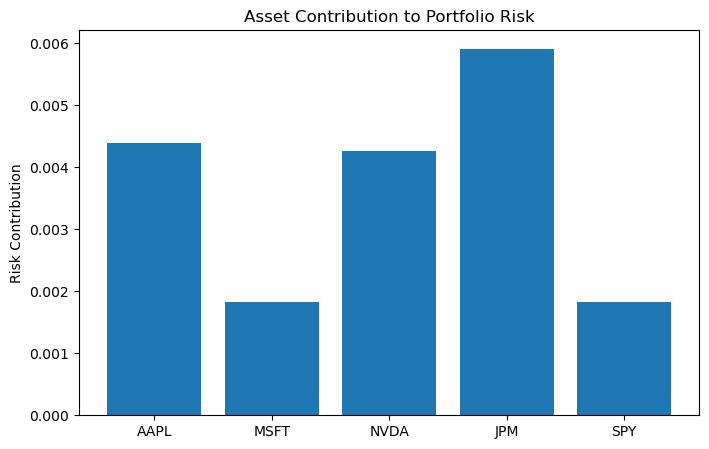

In [34]:
plt.figure(figsize=(8,5))

plt.bar(risk_contribution["ticker"], risk_contribution["risk_contribution"])

plt.title("Asset Contribution to Portfolio Risk")
plt.ylabel("Risk Contribution")

plt.savefig(f"{FIG_DIR}/day8_risk_contribution_chart.png", dpi=300)

plt.show()

In [1]:
asset_vol = returns_matrix.std()

asset_vol

NameError: name 'returns_matrix' is not defined

In [2]:
# Load portfolio data again
r = pd.read_sql("SELECT date, ticker, daily_return FROM returns;", engine)
w = pd.read_sql("SELECT ticker, weight FROM portfolio_weights;", engine)

r["date"] = pd.to_datetime(r["date"])

df = r.merge(w, on="ticker")

# Create returns matrix (assets x time)
returns_matrix = df.pivot(
    index="date",
    columns="ticker",
    values="daily_return"
)

returns_matrix = returns_matrix.dropna()

returns_matrix.head()

NameError: name 'pd' is not defined